In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt


import geopandas as gpd
from sklearn.metrics.pairwise import haversine_distances

In [2]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth's radius in km (use 3958.8 for miles)

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [3]:
growth = pd.read_csv('OptimizationInput\\ev_load_growth_from2025unmanaged_to2035managed_slice_hour_20.csv')
conMatrix = pd.read_csv('OptimizationInput\\feederBlockIntersectionMtx.csv')

add_load = growth['load'].to_numpy()
mat = conMatrix.to_numpy()
demand = mat@add_load

cap_max = pd.read_csv('OptimizationInput\\alamedaMinICA_slice_month6_hour20.csv')
cap_max['IC_min_kW'] = cap_max['IC_min_kW'].fillna(0)
maxes = cap_max['IC_min_kW'].to_numpy()

In [4]:
os.getcwd()

'c:\\Users\\thewo\\Documents\\Git\\OptimalChargerPlacement'

In [5]:
DATA_DIR = Path.cwd() / "data"

def import_census_block_gdf_for_charging(base_path=DATA_DIR):
    relative_folder_path = "Geography_Files"
    filename = "location_str_to_geoid_mapping.shp"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf = gpd.read_file(file_path)
    return gdf

def get_census_block_gdf_almada_charging():
    """
    Get census block geodataframe for Alameda county
    """
    df = import_census_block_gdf_for_charging()
    df = df[df["GEOID_STR"].str.contains("Alameda")]
    return df

alamedaCensusGdf = get_census_block_gdf_almada_charging()
alamedaCensusGdf['GEOID'] = alamedaCensusGdf['GEOID'].astype('int64')

In [6]:
alamedaCensusGdf.columns

Index(['GEOID', 'GEOID_STR', 'INTPTLAT', 'INTPTLON', 'geometry'], dtype='object')

In [7]:
len(alamedaCensusGdf)

1134

In [8]:
growth['geoid']

0       60014001001
1       60014002001
2       60014003001
3       60014004001
4       60014005001
           ...     
1069    60014010006
1070    60014087006
1071    60014261006
1072    60014334006
1073    60014381006
Name: geoid, Length: 1074, dtype: int64

In [9]:
good = alamedaCensusGdf[alamedaCensusGdf['GEOID'].isin(growth['geoid'])]

In [10]:
len(good)

1074

In [11]:
i = 0
dct = {}
pos = {}
for j, row in growth.iterrows():
    dct[i] = row['geoid']
    temp = good[good['GEOID']==row['geoid']]
    pos[i] = temp['INTPTLAT'].iloc[0], temp['INTPTLON'].iloc[0] 
    i+= 1

In [12]:
pos[0]

(np.float64(37.869878), np.float64(-122.2336208))

In [13]:
dist = np.zeros((1074,1074))
for i in range(1074):
    for j in range(i, 1074):
        lat1, lon1 = pos[i]
        lat2, lon2 = pos[j]
        dist[i,j] = haversine(lat1, lon1, lat2, lon2)
        dist[j,i] = dist[i,j]



In [14]:
dist[:5,:5]

array([[0.        , 2.607422  , 3.16774889, 2.89050832, 3.4907805 ],
       [2.607422  , 0.        , 0.64071328, 0.53909775, 1.26343465],
       [3.16774889, 0.64071328, 0.        , 0.87598848, 1.38776936],
       [2.89050832, 0.53909775, 0.87598848, 0.        , 0.73426962],
       [3.4907805 , 1.26343465, 1.38776936, 0.73426962, 0.        ]])

In [15]:
len(dct)

1074

In [16]:
add_load

array([247.48800501, 134.25600192, 189.16000147, ...,  40.00000107,
       118.36000123,  74.36000195], shape=(1074,))

In [17]:
mat.shape

(303, 1074)

In [18]:
n = 303
m = 1074
Cmval = 1+np.random.rand(m,m)*25
np.fill_diagonal(Cmval, 1)
Cmval = np.square(Cmval)

In [19]:

ni = cp.Variable(n, boolean=True)
x = cp.Variable(n)
y = cp.Variable((m,m))
d = cp.Variable(m)

Cu = cp.Parameter(nonneg=True)
Cf = cp.Parameter(nonneg=True)
Cu = 0.025
Cf = 100
Cm = cp.Parameter((m,m))
Cm.value = np.square(dist)*0.5
loads = cp.Parameter(m)
loads = add_load*30

# Replace with distance matrix
M=10**6


In [20]:
obj = Cf*cp.sum(ni) + Cu*cp.sum(x) + cp.sum(cp.multiply(Cm, y))

constraints = []
constraints += [x <= ni*M, x >= 0, y >= 0, d>=0]

constraints += [x+maxes >= mat@d]
for i in range(m):
    constraints += [cp.sum(y[i,:]) >= loads[i]]
    constraints += [d[i] == cp.sum(y[:,i])-cp.sum(y[i,:])+y[i,i]]

prob = cp.Problem(cp.Minimize(obj), constraints)


In [21]:
np.sum(mat, axis=1).shape

(303,)

In [22]:
loads.value = add_load*100

AttributeError: 'numpy.ndarray' object has no attribute 'value' and no __dict__ for setting new attributes

In [ ]:
prob.solve(verbose=True,ignore_dpp=True)

(CVXPY) Dec 12 04:40:32 PM: Your problem has 1155156 variables, 1157607 constraints, and 1153476 parameters.
(CVXPY) Dec 12 04:40:32 PM: It is compliant with the following grammars: DCP, DQCP


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) Dec 12 04:40:32 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Dec 12 04:40:32 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Dec 12 04:40:32 PM: Compiling problem (target solver=SCIPY).
(CVXPY) Dec 12 04:40:32 PM: Reduction chain: EvalParams -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCIPY
(CVXPY) Dec 12 04:40:32 PM: Applying reduction EvalParams
(CVXPY) Dec 12 04:40:32 PM: Applying reduction Dcp2Cone
(CVXPY) Dec 12 04:40:32 PM: Applying reduction CvxAttr2Constr
(CVXPY) Dec 12 04:40:32 PM: Applying reduction ConeMatrixStuffing


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Dec 12 04:45:02 PM: Applying reduction SCIPY
(CVXPY) Dec 12 04:45:03 PM: Finished problem compilation (took 2.707e+02 seconds).
(CVXPY) Dec 12 04:45:03 PM: Invoking solver SCIPY  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


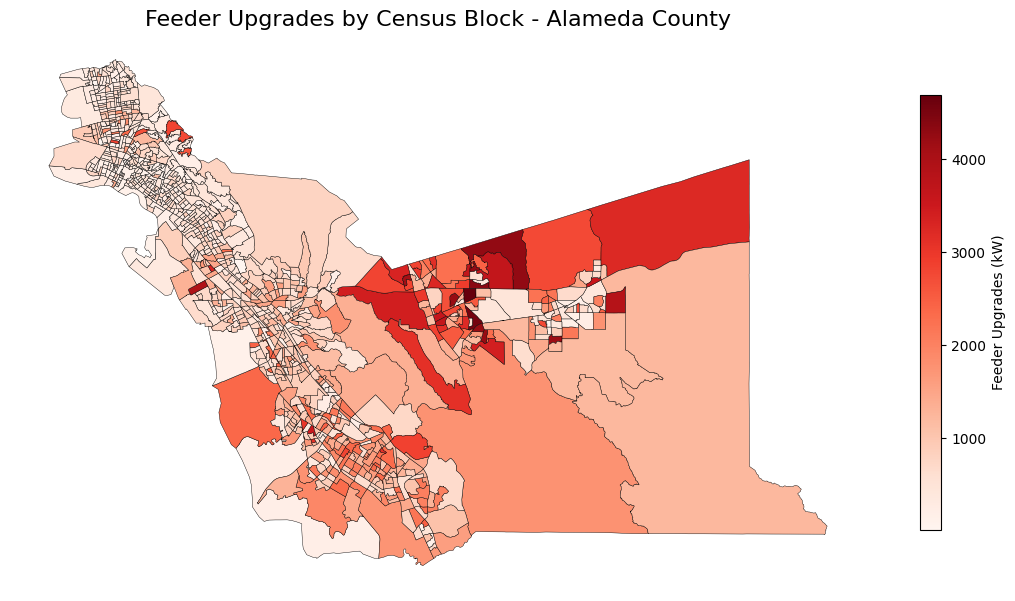

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))

good.plot(
    ax=ax,
    column='upgrades',
    # cmap='YlOrRd',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Upgrades (kW)',
        'orientation': 'vertical',
        'shrink': 0.5
    }
)

plt.title('Feeder Upgrades by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
inv = {v: k for k, v in dct.items()}

In [ ]:
movement = np.sum(y.value, axis=1)-np.diagonal(y.value)

In [ ]:
move2 = np.sum(y.value, axis=0)-loads

In [ ]:
good['movement'] = movement

c:\Users\thewo\Documents\Git\.default13\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


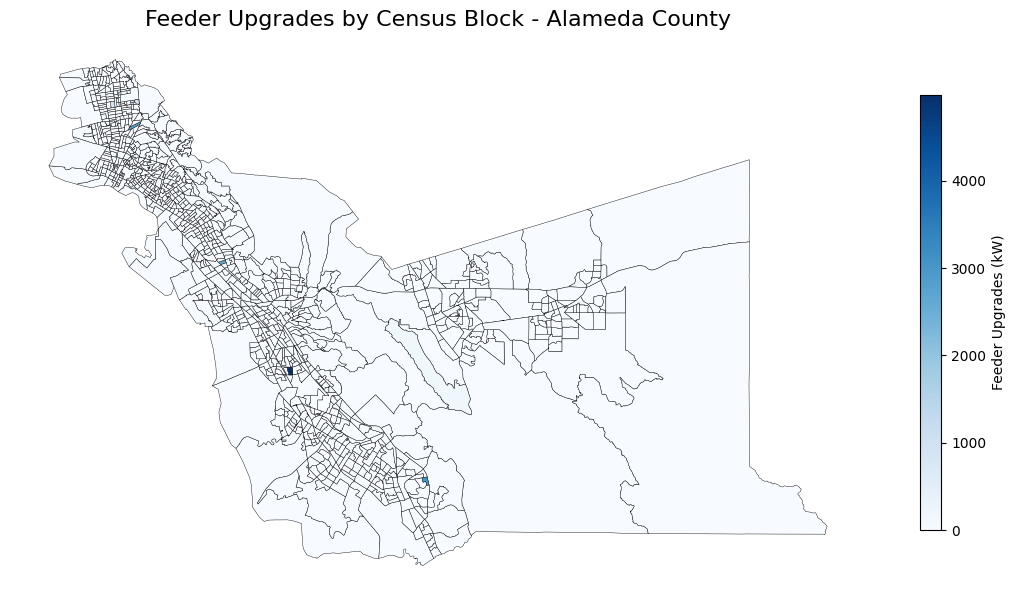

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))

good.plot(
    ax=ax,
    column='movement',
    # cmap='YlOrRd',
    cmap='Blues',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Upgrades (kW)',
        'orientation': 'vertical',
        'shrink': 0.5
    }
)

plt.title('Feeder Upgrades by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
upgrades = x.value@mat

In [ ]:
good['upgrades'] = good['upgrades']/30

In [ ]:
ls = []
for i, row in good.iterrows():
    ls.append(upgrades[inv[row['GEOID']]])

In [ ]:
good['upgrades'] = ls

In [ ]:
good['upgrades']

0         8057.415261
2         4739.644141
15        3334.344169
29       25475.563763
54       35919.186582
             ...     
27442     6013.866405
27445    23662.405796
27458    25475.563763
27464     8707.840153
27495    12659.299523
Name: upgrades, Length: 1074, dtype: float64

In [ ]:
np.sum(add_load)*30

np.float64(4772633.584230779)

In [ ]:
np.sum(ni.value >= 0.1)

np.int64(258)

In [ ]:
np.sum(y.value)

np.float64(9611595.334379097)

In [ ]:
np.sum(d.value)

np.float64(499552.5541163961)

In [ ]:
np.sum(maxes)

np.float64(626337.3502994999)

In [ ]:
x.value

array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0

In [ ]:
def saveAll(filename, x, y, ni):
    with open(filename, 'wb') as file:
        np.save(file, x)
        np.save(file, y)
        np.save(file, ni)

def loadAll(filename):
    with open(filename, 'rb') as file:
        x = np.load(file)
        y = np.load(file)
        ni = np.load(file)
    return x,y,ni

In [ ]:
saveAll('data/moverun.npz', x.value, y.value, ni.value)

In [ ]:
y.value

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(1074, 1074))

In [ ]:
mat@d.value

array([0.00000000e+00, 1.31394708e-13, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.87956840e+03, 1.72623660e+03,
       9.68602909e+02, 2.41120920e+03, 2.96303690e+03, 2.33476590e+03,
       1.57633157e+03, 1.70578230e+03, 1.30092470e+03, 1.78438082e+03,
       6.61163353e+01, 1.59594260e+03, 2.15405359e+03, 9.27579390e+01,
       1.79311080e+03, 9.29383339e+02, 0.00000000e+00, 0.00000000e+00,
       6.47407400e+02, 9.41493367e-13, 6.49995204e+02, 2.48015200e+03,
       7.35498464e+02, 0.00000000e+00, 1.66668800e+03, 1.67197440e+03,
       2.99390000e+03, 2.03474740e+03, 1.29857140e+03, 1.32835685e-13,
       2.37186200e+03, 3.56164120e+02, 3.22665534e+03, 2.21985670e+03,
       2.11760910e+03, 2.09981030e+03, 2.64725189e+03, 2.43125220e+03,
       4.98157125e+02, 3.33050840e+02, 7.68653900e+02, 5.55853640e+02,
       2.68880540e+02, 0.00000000e+00, 3.12611192e+02, 4.08542005e+02,
       6.17580600e+02, 6.84321000e+02, 7.33217400e+02, 3.00917750e+03,
      

In [ ]:
x.value

array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0

In [ ]:
i=13
np.sum(y.value[i,:]) - add_load[i]*30

np.float64(29758.147588093976)

In [ ]:
growth.columns

Index(['geoid', 'geoid_str', 'load'], dtype='object')

In [ ]:
np.sum(y.value[1,:])

np.float64(2685.1200383901587)

In [ ]:
demand

array([3.88316848e+01, 1.01421681e+02, 5.73582451e+01, 7.48227969e+01,
       3.62526029e+01, 8.87732264e+01, 1.89056942e+02, 6.67578838e+02,
       4.03278168e+01, 2.45097242e+02, 3.48055382e+02, 3.60334948e+02,
       3.22176206e+02, 4.06476365e+02, 1.61389590e+02, 8.35210625e+01,
       1.16398763e+01, 6.02493148e+01, 1.64630856e+02, 1.76618950e+01,
       2.16441463e+02, 6.28534641e+01, 5.71736776e+01, 5.60600639e+01,
       7.15250510e+01, 9.06410984e+01, 5.14983953e+01, 8.23835198e+01,
       8.34626795e+01, 1.81552904e+02, 6.68104450e+02, 1.41648989e+02,
       1.10356311e+02, 4.92528206e+02, 1.61517107e+02, 4.12442660e+02,
       2.61895959e+02, 2.87384374e+02, 8.87976663e+01, 3.24359070e+02,
       4.09775881e+02, 2.58096242e+02, 1.36707534e+02, 6.36783827e+02,
       4.25993651e+01, 1.49499352e+02, 1.20745268e+02, 1.26996507e+02,
       3.48364929e+01, 8.03795239e+01, 4.11227169e+01, 1.41194240e+01,
       1.71998361e+02, 1.36330299e+02, 1.48181820e+02, 2.33593988e+02,
      

In [ ]:
cap_max['IC_min_kW'] = cap_max['IC_min_kW'].fillna(0)

In [ ]:
cap_max

,feeder_id,IC_min_kW
0,12011101,0.0000
1,12011102,0.0000
2,12011103,0.0000
3,12011104,0.0000
4,12011105,0.0000
...,...,...
298,14722111,4084.2234
299,82831109,1269.2465
300,163741102,224.9415
301,163741103,357.6861


In [ ]:
maxes = cap_max['IC_min_kW'].to_numpy()

In [ ]:
demand > maxes

array([ True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False,  True, False, False, False, False,  True,
       False, False,

In [ ]:
np.sum(demand)-np.sum(maxes)

np.float64(-467249.564158474)

In [ ]:
np.sum(demand)

np.float64(159087.78614102595)